# Parte 2:

## Análisis de Delitos en EE.UU (1970) mediante Escalamiento Multidimensional

### Contexto
Se analiza una base de datos de actos delictivos en EE.UU. del año 1970. La tabla `crimes.dat` contiene correlaciones entre la ocurrencia de 7 clases de delitos.

### Definición de Distancia
Para cada par de delitos (clases), se define la distancia como:

$$
d(x_i, x_j) = 1 - \rho_{ij}
$$

### Objetivo
Aplicar **escalamiento multidimensional (MDS)** para visualizar las observaciones en un espacio de menor dimensión e interpretar el primer eje principal.

### Importar y visualizar los datos

In [11]:
import pandas as pd

# Importar el archivo crimes.dat. Ajusta el parámetro sep si es necesario (aquí se asume que es CSV separado por comas)
df = pd.read_csv("datasets/crimes.dat", sep=",", skipinitialspace=True)

# Visualizamos el DataFrame importado
print("Datos importados:")
print(df.head())

# Configuramos la columna 'Crime' como índice para trabajar cómodamente
df.set_index("Crime", inplace=True)
print("\nDataFrame con índice 'Crime':")
print(df)


Datos importados:
      Crime  No.     1     2     3     4     5     6     7
0    Murder    1  1.00  0.52  0.34  0.81  0.28  0.06  0.11
1      Rape    2  0.52  1.00  0.55  0.70  0.68  0.60  0.44
2   Robbery    3  0.34  0.55  1.00  0.56  0.62  0.44  0.62
3   Assault    4  0.81  0.70  0.56  1.00  0.52  0.32  0.33
4  Burglary    5  0.28  0.68  0.62  0.52  1.00  0.80  0.70

DataFrame con índice 'Crime':
            No.     1     2     3     4     5     6     7
Crime                                                    
Murder        1  1.00  0.52  0.34  0.81  0.28  0.06  0.11
Rape          2  0.52  1.00  0.55  0.70  0.68  0.60  0.44
Robbery       3  0.34  0.55  1.00  0.56  0.62  0.44  0.62
Assault       4  0.81  0.70  0.56  1.00  0.52  0.32  0.33
Burglary      5  0.28  0.68  0.62  0.52  1.00  0.80  0.70
Larceny       6  0.06  0.60  0.44  0.32  0.80  1.00  0.55
Auto theft    7  0.11  0.44  0.62  0.33  0.70  0.55  1.00


### Preparación de la matriz de correlaciones

In [12]:
# La tabla incluye una columna "No.", que no es necesaria para el análisis de correlación. La eliminamos.
correlation_matrix = df.drop(columns=["No."]).astype(float)
print("\nMatriz de correlaciones:")
print(correlation_matrix)



Matriz de correlaciones:
               1     2     3     4     5     6     7
Crime                                               
Murder      1.00  0.52  0.34  0.81  0.28  0.06  0.11
Rape        0.52  1.00  0.55  0.70  0.68  0.60  0.44
Robbery     0.34  0.55  1.00  0.56  0.62  0.44  0.62
Assault     0.81  0.70  0.56  1.00  0.52  0.32  0.33
Burglary    0.28  0.68  0.62  0.52  1.00  0.80  0.70
Larceny     0.06  0.60  0.44  0.32  0.80  1.00  0.55
Auto theft  0.11  0.44  0.62  0.33  0.70  0.55  1.00


### Cálculo de la matriz de distancias

In [13]:
# Definimos la distancia entre dos variables como: distancia = 1 - correlación
distance_matrix = 1 - correlation_matrix
print("\nMatriz de distancias:")
print(distance_matrix)


Matriz de distancias:
               1     2     3     4     5     6     7
Crime                                               
Murder      0.00  0.48  0.66  0.19  0.72  0.94  0.89
Rape        0.48  0.00  0.45  0.30  0.32  0.40  0.56
Robbery     0.66  0.45  0.00  0.44  0.38  0.56  0.38
Assault     0.19  0.30  0.44  0.00  0.48  0.68  0.67
Burglary    0.72  0.32  0.38  0.48  0.00  0.20  0.30
Larceny     0.94  0.40  0.56  0.68  0.20  0.00  0.45
Auto theft  0.89  0.56  0.38  0.67  0.30  0.45  0.00


### Aplicación de MDS


Coordenadas MDS:
                Dim1      Dim2
Crime                         
Murder      0.209602  0.490927
Rape       -0.102982  0.131432
Robbery     0.238000 -0.145618
Assault     0.125229  0.283502
Burglary   -0.145242 -0.151237
Larceny    -0.350925 -0.203749
Auto theft  0.026318 -0.405257


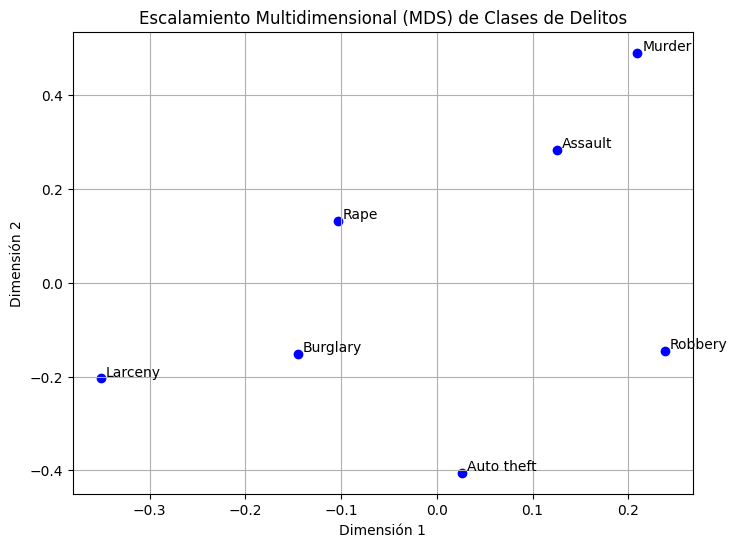

In [14]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

# Configuramos y aplicamos el MDS utilizando la matriz de distancias
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
mds_results = mds.fit_transform(distance_matrix)

# Creamos un DataFrame con las coordenadas obtenidas
mds_df = pd.DataFrame(mds_results, columns=["Dim1", "Dim2"], index=correlation_matrix.index)
print("\nCoordenadas MDS:")
print(mds_df)

# Visualización de los resultados
plt.figure(figsize=(8, 6))
plt.scatter(mds_df["Dim1"], mds_df["Dim2"], color="blue")
for crime in mds_df.index:
    plt.text(mds_df.loc[crime, "Dim1"] + 0.005, mds_df.loc[crime, "Dim2"] + 0.005, crime)
plt.title("Escalamiento Multidimensional (MDS) de Clases de Delitos")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.grid(True)
plt.show()


### Interpretación del Primer Eje Principal con PCA


Cargas PCA:
                 PC1       PC2
Crime                         
Murder      0.591595  0.073182
Rape        0.038288  0.516457
Robbery    -0.117235 -0.414929
Assault     0.379742  0.146707
Burglary   -0.328993  0.269361
Larceny    -0.457468  0.543325
Auto theft -0.416039 -0.408009


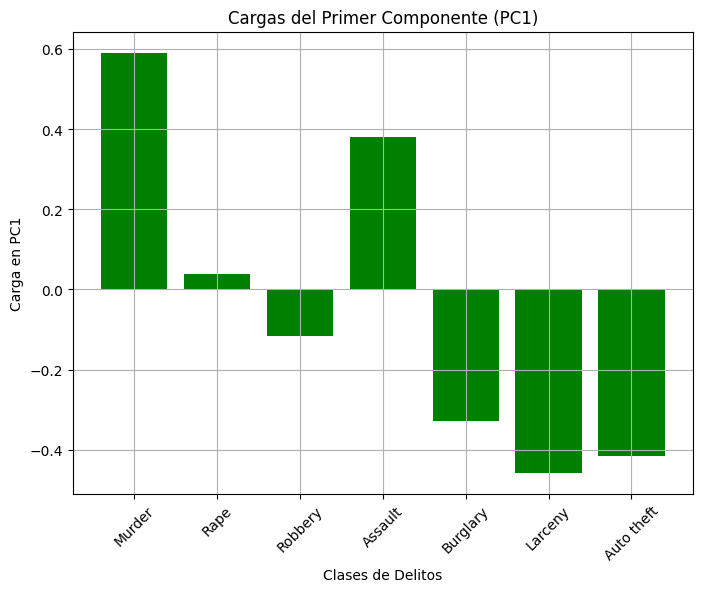

In [15]:
from sklearn.decomposition import PCA

# Aplicamos PCA sobre la matriz de correlación para interpretar el primer eje principal.
pca = PCA(n_components=2)
pca_results = pca.fit_transform(correlation_matrix)

# Creamos un DataFrame para visualizar las cargas de cada variable en los componentes
pca_df = pd.DataFrame(pca.components_.T, index=correlation_matrix.index, columns=["PC1", "PC2"])
print("\nCargas PCA:")
print(pca_df)

# Visualizamos las cargas del primer componente
plt.figure(figsize=(8, 6))
plt.bar(pca_df.index, pca_df["PC1"], color="green")
plt.title("Cargas del Primer Componente (PC1)")
plt.xlabel("Clases de Delitos")
plt.ylabel("Carga en PC1")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


# Compresión de Imágenes mediante PCA aplicada a bloques (usando SVD)

### Contexto

Se subdivide una imagen (en escala de grises) en bloques de tamaño \(C \times C\). Cada bloque se vectoriza y se forma la matriz \(X\), donde cada fila es un bloque. Aplicamos SVD (equivalente a PCA) sobre \(X\) y reconstruimos cada bloque usando solo los primeros \( k \) componentes. Luego reensamblamos la imagen completa y evaluamos el efecto de \( k \) sobre la calidad y el error de reconstrucción.

### Objetivo

Comparar la imagen reconstruida para distintos valores de \( k \) y calcular el error (MSE) en la reconstrucción.


### Importación de librerías y carga de la imagen

Dimensiones de la imagen (grayscale): (764, 1368)


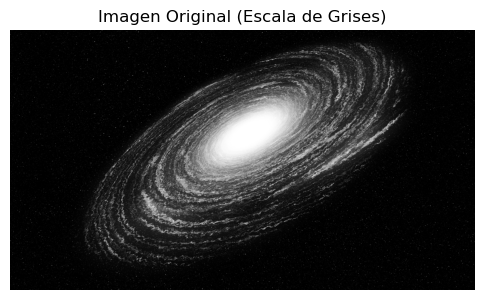

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray

# Cargamos la imagen (asegúrate de que 'quetzal.png' esté en el directorio de trabajo)
I = plt.imread('Space1.png')
# Si la imagen tiene canal alfa o más de 3 canales, tomamos los 3 primeros
if I.ndim == 3 and I.shape[2] > 3:
    I = I[:, :, :3]

# Convertimos a escala de grises
Igray = rgb2gray(I)
print("Dimensiones de la imagen (grayscale):", Igray.shape)

# Visualizamos la imagen original
plt.figure(figsize=(6,6))
plt.imshow(Igray, cmap='gray')
plt.title("Imagen Original (Escala de Grises)")
plt.axis('off')
plt.show()



### Función para extraer bloques de la imagen

Se divide la imagen en bloques de tamaño \(C \times C\) y se vectoriza cada bloque.



In [32]:
def extract_blocks(img, block_size):
    H, W = img.shape
    C = block_size
    n_blocks_vertical = H // C
    n_blocks_horizontal = W // C
    blocks = []
    for i in range(n_blocks_vertical):
        for j in range(n_blocks_horizontal):
            block = img[i*C:(i+1)*C, j*C:(j+1)*C]
            blocks.append(block.flatten())
    return np.array(blocks), n_blocks_vertical, n_blocks_horizontal

# Elegimos el tamaño de bloque (asegúrate de que C divida a las dimensiones de la imagen)
C = 8
X, n_vert, n_horiz = extract_blocks(Igray, C)
print(f"Se extrajeron {X.shape[0]} bloques de tamaño {C}x{C} (cada bloque vectorizado en dimensión {C**2}).")


Se extrajeron 16245 bloques de tamaño 8x8 (cada bloque vectorizado en dimensión 64).


### Centrando los datos y aplicando SVD

Se centra la matriz \(X\) y se aplica SVD para obtener la descomposición: 
 \[X_c = U S V^T\]

Donde \(X_c\) es \(X\) centrada (se resta la media de cada columna).



In [33]:
# Centramos la matriz X (restamos la media de cada columna)
mu = X.mean(axis=0)
Xc = X - mu

# Aplicamos SVD a la matriz centrada
U, S, VT = np.linalg.svd(Xc, full_matrices=False)
print("Formas de U, S y VT:", U.shape, S.shape, VT.shape)

Formas de U, S y VT: (16245, 64) (64,) (64, 64)


### Reconstrucción de bloques usando diferentes números de componentes \( k \)
 Para cada valor de \( k \), reconstruimos la matriz aproximada:
 \[ X_{approx} = U_{[:, :k]} \cdot \mathrm{diag}(S_{[:k]}) \cdot V_{[:k, :]},\]

y luego sumamos la media \( \mu \) para recuperar la escala original. Finalmente, reensamblamos la imagen a partir de los bloques reconstruidos.



In [38]:
# Valores de k a probar (k = número de componentes)
ks = [1, 2, 5, 16, 20, 32, C*C]  # C*C es la reconstrucción exacta
reconstructions = {}
errors = {}

def reconstruct_image_from_blocks(blocks, n_vert, n_horiz, block_size):
    H = n_vert * block_size
    W = n_horiz * block_size
    rec_img = np.zeros((H, W))
    idx = 0
    for i in range(n_vert):
        for j in range(n_horiz):
            block = blocks[idx].reshape((block_size, block_size))
            rec_img[i*block_size:(i+1)*block_size, j*block_size:(j+1)*block_size] = block
            idx += 1
    return rec_img

for k in ks:
    # Reconstrucción usando k componentes
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    VT_k = VT[:k, :]
    X_approx = U_k @ S_k @ VT_k
    # Sumamos la media para recuperar la escala original
    X_rec = X_approx + mu
    # Reensamblamos la imagen
    rec_img = reconstruct_image_from_blocks(X_rec, n_vert, n_horiz, C)
    reconstructions[k] = rec_img
    # Calculamos el error MSE entre la imagen original (en la zona cubierta por los bloques) y la reconstruida
    # Nota: si la imagen original no es múltiplo de C, solo comparamos la parte reconstruida.
    H_rec, W_rec = rec_img.shape
    mse = np.mean((Igray[:H_rec, :W_rec] - rec_img)**2)
    errors[k] = mse
    print(f"k = {k}, MSE = {mse:.6f}")


k = 1, MSE = 0.004137
k = 2, MSE = 0.003435
k = 5, MSE = 0.002419
k = 16, MSE = 0.001083
k = 20, MSE = 0.000842
k = 32, MSE = 0.000401
k = 64, MSE = 0.000000


### Visualización de las imágenes reconstruidas y análisis del error
 
Se muestran la imagen original y las reconstrucciones para los diferentes valores de \( k \). También se grafica el error de reconstrucción en función de \( k \).



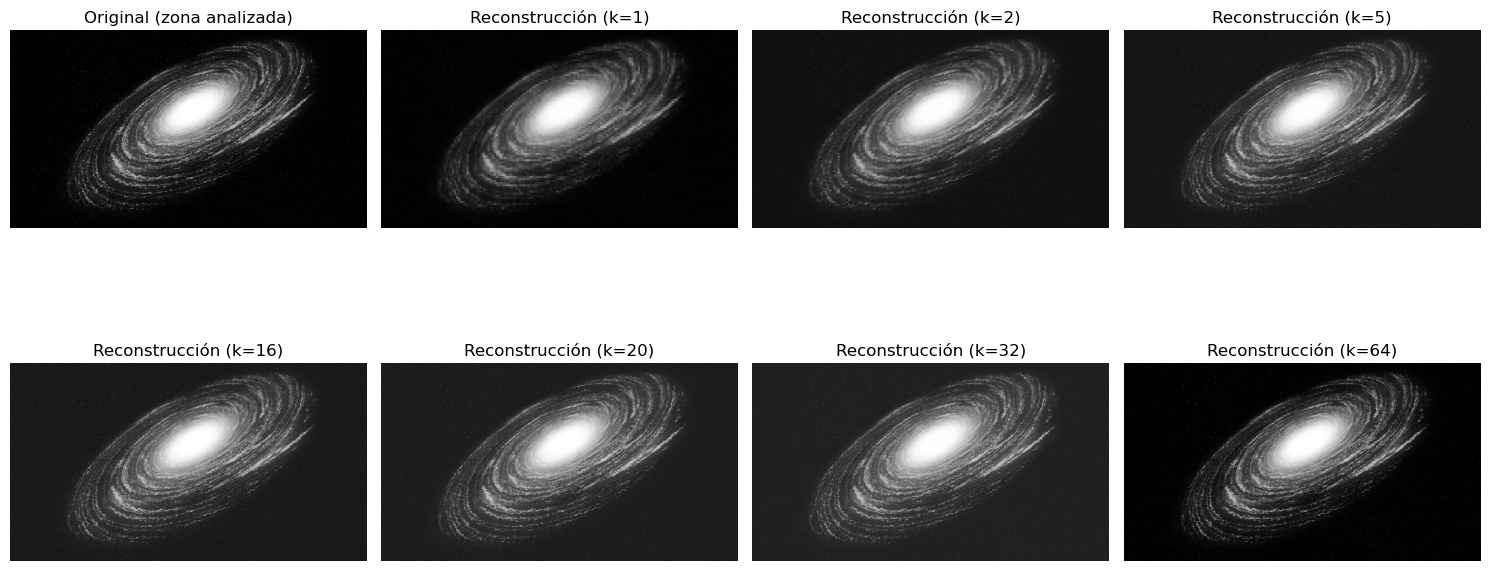

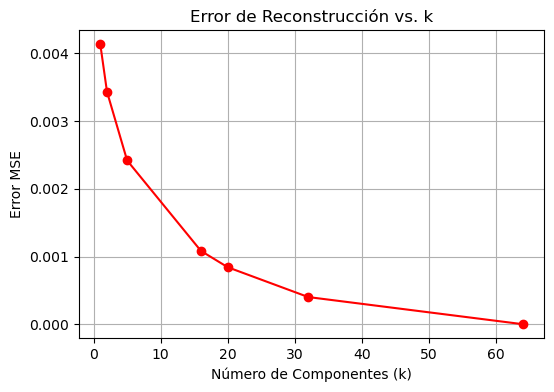

In [39]:
# Visualización de la imagen original y las reconstrucciones
plt.figure(figsize=(15,8))
n_plots = len(ks) + 1

plt.subplot(2, (n_plots+1)//2, 1)
plt.imshow(Igray[:reconstructions[ks[-1]].shape[0], :reconstructions[ks[-1]].shape[1]], cmap='gray')
plt.title("Original (zona analizada)")
plt.axis('off')

for i, k in enumerate(ks, start=2):
    plt.subplot(2, (n_plots+1)//2, i)
    plt.imshow(reconstructions[k], cmap='gray')
    plt.title(f"Reconstrucción (k={k})")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Graficamos el error de reconstrucción (MSE) en función de k
plt.figure(figsize=(6,4))
plt.plot(list(errors.keys()), list(errors.values()), marker='o', color="red")
plt.xlabel("Número de Componentes (k)")
plt.ylabel("Error MSE")
plt.title("Error de Reconstrucción vs. k")
plt.grid(True)
plt.show()

# Conclusión

A medida que se incrementa el número de componentes principales k, el error de reconstrucción (MSE) disminuye de manera significativa. Con valores muy bajos de k (por ejemplo, k=2), se observa una pérdida considerable de detalles en la imagen, lo cual se traduce en un error más alto. Sin embargo, conforme k aumenta, la reconstrucción se hace cada vez más fiel al original.

Al llegar a k=64 (que coincide con la dimensión total del bloque en este ejemplo), la reconstrucción es prácticamente exacta (MSE≈0), porque en ese punto se está usando toda la información disponible.

Este comportamiento ilustra el compromiso entre compresión y calidad: Un k pequeño implica mayor compresión (menos datos que almacenar o transmitir) pero más error en la reconstrucción.

Un k grande retiene más información y reduce el error, aunque también disminuye la tasa de compresión.

En la práctica, se elige un k intermedio que ofrezca un equilibrio adecuado entre el nivel de detalle requerido y el ahorro de espacio/recursos deseado.

